# 03 — Initial EDA (position-aware)

Exploratory look at `data/processed/player_season.csv`, prepared for the
second instructor meeting. Six figures and two small correlation tables.
Everything here is **associational**: no causal claims, no modeling.

Conventions:

- Market value is plotted on a **log scale** (raw skew ~5; see §1), with
  axes labeled in EUR.
- Position-aware: per-90 goal/assist stats are only shown for positions where
  they mean something, and only for rows with `analysis_minutes_eligible`
  (>= 450 minutes).
- League is a known confounder (§6); it is shown, not yet controlled for.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

df = pd.read_csv("../data/processed/player_season.csv")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 80  # inline preview only; saved figures use dpi=150

POS_ORDER = ["Goalkeeper", "Defender", "Midfield", "Attack"]
POS_COLORS = {"Goalkeeper": "#E69F00", "Defender": "#0072B2", "Midfield": "#009E73", "Attack": "#D55E00"}
MV = "market_value_in_eur"
elig = df[df["analysis_minutes_eligible"]]

def eur(v):
    return f"€{v/1e6:g}M" if v >= 1e6 else f"€{v/1e3:g}K"
log_eur_axis = FuncFormatter(lambda v, _: eur(v))

print(f"{len(df):,} player-season rows; {len(elig):,} eligible for per-90 analysis")
print(df["position"].value_counts().reindex(POS_ORDER).to_string())

32,046 player-season rows; 23,328 eligible for per-90 analysis
position
Goalkeeper     2560
Defender      10942
Midfield       9428
Attack         9116


## 0. Data coverage and exclusions

What was dropped to get from the raw player-season build to the analysis
table (from `02_build_player_season.ipynb`).

In [2]:
pd.read_csv("../data/processed/exclusion_summary.csv")

,step,rows_dropped,rows_remaining
0,"Initial player-seasons in scope (14 leagues, 2...",0,32966
1,Missing position,9,32957
2,Missing date of birth,5,32952
3,No valuation on/before July 31 cutoff,490,32462
4,Valuation older than 365 days at cutoff,416,32046
5,Zero total minutes,0,32046
6,Of final rows: eligible for per-90 analysis (>...,8718,23328


## 1. Skew check: raw vs log scale

Not saved -- only to decide the scale.

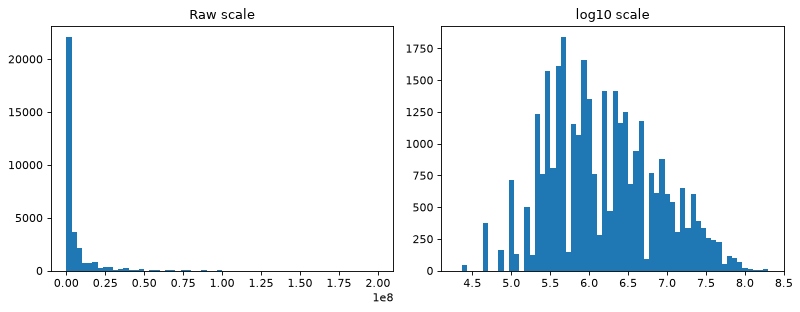

skewness (raw): 5.25
skewness (log10): 0.28


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df[MV], bins=60)
axes[0].set_title("Raw scale")
axes[1].hist(np.log10(df[MV]), bins=60)
axes[1].set_title("log10 scale")
plt.tight_layout()
plt.show()
print("skewness (raw):", round(df[MV].skew(), 2))
print("skewness (log10):", round(np.log10(df[MV]).skew(), 2))

Raw market value is heavily right-skewed; log10 is close to symmetric.
**All value plots below use a log scale.**

## Figure 1. Market value distribution

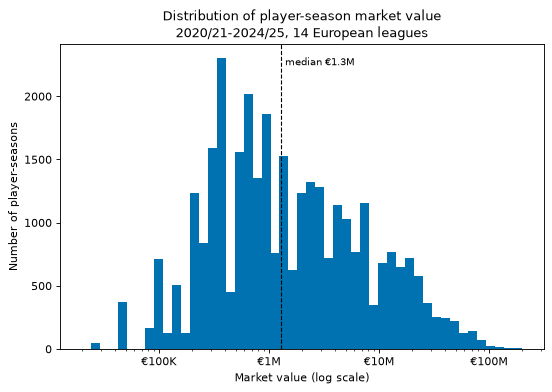

In [4]:
bins = np.logspace(np.log10(df[MV].min()), np.log10(df[MV].max()), 50)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df[MV], bins=bins, color="#0072B2")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(log_eur_axis)
ax.axvline(df[MV].median(), color="black", ls="--", lw=1)
ax.text(df[MV].median() * 1.08, ax.get_ylim()[1] * 0.93, f"median {eur(df[MV].median())}", fontsize=9)
ax.set_xlabel("Market value (log scale)")
ax.set_ylabel("Number of player-seasons")
ax.set_title("Distribution of player-season market value\n2020/21-2024/25, 14 European leagues")
fig.tight_layout()
fig.savefig(FIG_DIR / "market_value_distribution.png", dpi=150)
plt.show()

## Figure 2. Market value vs age (all positions pooled)

Hexbin density instead of a 32k-point scatter; the line is the median value
at each whole-year age.

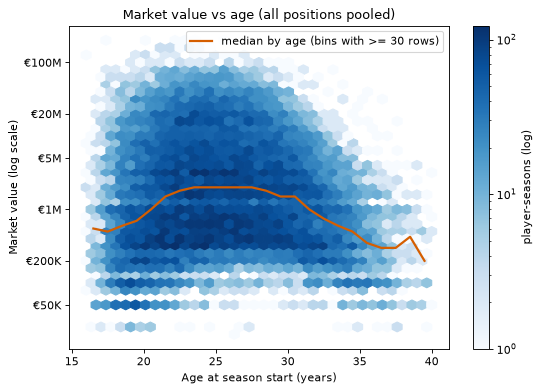

In [5]:
a = df[(df["age"] >= 16) & (df["age"] <= 40)]
grp = a.groupby(a["age"].astype(int))[MV].agg(["median", "size"])
med = grp.loc[grp["size"] >= 30, "median"]
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(a["age"], np.log10(a[MV]), gridsize=35, mincnt=1, bins="log", cmap="Blues")
ax.plot(med.index + 0.5, np.log10(med.values), color="#D55E00", lw=2, label="median by age (bins with >= 30 rows)")
ticks = [5e4, 2e5, 1e6, 5e6, 2e7, 1e8]
ax.set_yticks(np.log10(ticks)); ax.set_yticklabels([eur(t) for t in ticks])
ax.set_xlabel("Age at season start (years)")
ax.set_ylabel("Market value (log scale)")
ax.set_title("Market value vs age (all positions pooled)")
fig.colorbar(hb, ax=ax, label="player-seasons (log)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "market_value_vs_age.png", dpi=150)
plt.show()

## Figure 3. Market value by main position

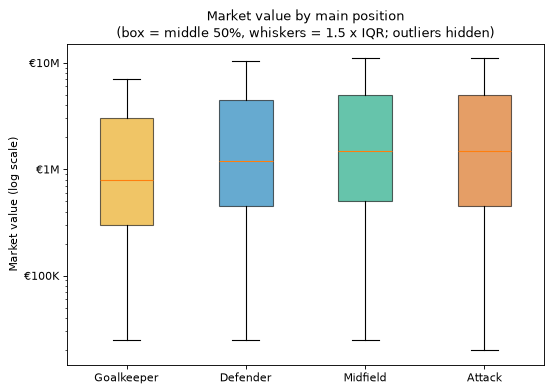

,count,25%,50%,75%,max
position,,,,,
Goalkeeper,2560.0,300000.0,800000.0,3000000.0,70000000.0
Defender,10942.0,450000.0,1200000.0,4500000.0,80000000.0
Midfield,9428.0,500000.0,1500000.0,5000000.0,180000000.0
Attack,9116.0,450000.0,1500000.0,5000000.0,200000000.0


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot([df.loc[df["position"] == p, MV] for p in POS_ORDER], tick_labels=POS_ORDER,
                showfliers=False, patch_artist=True)
for patch, p in zip(bp["boxes"], POS_ORDER):
    patch.set_facecolor(POS_COLORS[p]); patch.set_alpha(0.6)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(log_eur_axis)
ax.set_ylabel("Market value (log scale)")
ax.set_title("Market value by main position\n(box = middle 50%, whiskers = 1.5 x IQR; outliers hidden)")
fig.tight_layout()
fig.savefig(FIG_DIR / "market_value_by_position.png", dpi=150)
plt.show()
df.groupby("position")[MV].describe()[["count", "25%", "50%", "75%", "max"]].reindex(POS_ORDER)

Whiskers hide the outliers on purpose; the table above includes the maxima
(the highest-valued players are attackers and midfielders).

## Figure 4. Median market value by age, by position

Median over whole-year age bins; bins with fewer than 30 player-seasons are
dropped.

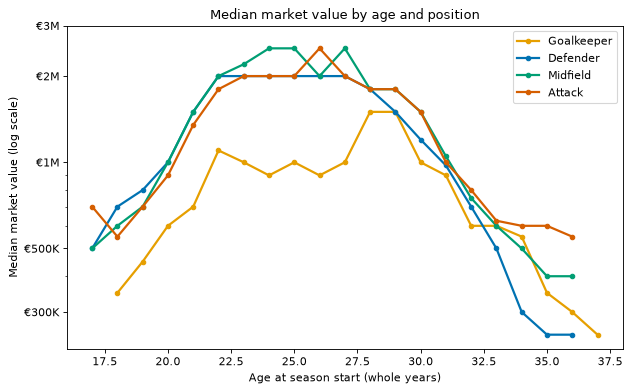

age bin with highest median value, per position:
            age_bin     median    n
position                           
Goalkeeper       28  1500000.0  169
Defender         22  2000000.0  852
Midfield         24  2500000.0  753
Attack           26  2500000.0  641


In [7]:
a = df[(df["age"] >= 17) & (df["age"] <= 38)].copy()
a["age_bin"] = a["age"].astype(int)
g = a.groupby(["position", "age_bin"])[MV].agg(median="median", n="size").reset_index()
g = g[g["n"] >= 30]

fig, ax = plt.subplots(figsize=(8, 5))
for p in POS_ORDER:
    s = g[g["position"] == p]
    ax.plot(s["age_bin"], s["median"], marker="o", ms=4, lw=2, color=POS_COLORS[p], label=p)
ax.set_yscale("log")
ax.set_yticks([3e5, 5e5, 1e6, 2e6, 3e6])
ax.yaxis.set_major_formatter(log_eur_axis)
ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
ax.set_xlabel("Age at season start (whole years)")
ax.set_ylabel("Median market value (log scale)")
ax.set_title("Median market value by age and position")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "market_value_by_age_position.png", dpi=150)
plt.show()

peak = g.loc[g.groupby("position")["median"].idxmax()].set_index("position").reindex(POS_ORDER)
print("age bin with highest median value, per position:")
print(peak[["age_bin", "median", "n"]].to_string())

## Figure 5. Performance vs market value, by position

Only `analysis_minutes_eligible` rows (>= 450 min). Goals/90 for attackers
and assists/90 for midfielders and attackers; the line is the median value
within deciles of the x variable. Defenders and goalkeepers are deliberately
not shown against goals/assists -- those aren't their main contribution and
this dataset has no defensive/goalkeeping stats.

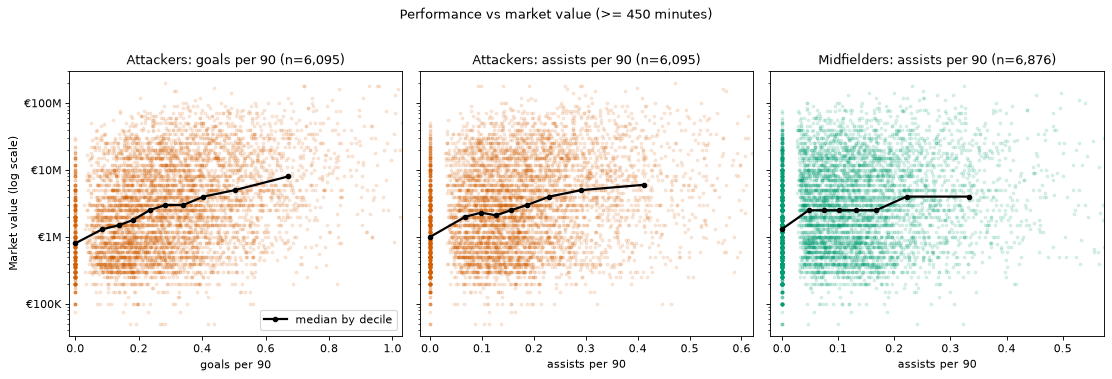

In [8]:
panels = [("Attack", "goals_per_90", "Attackers: goals per 90"),
          ("Attack", "assists_per_90", "Attackers: assists per 90"),
          ("Midfield", "assists_per_90", "Midfielders: assists per 90")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
for ax, (pos, col, title) in zip(axes, panels):
    s = elig[elig["position"] == pos]
    xmax = s[col].quantile(0.995)
    ax.scatter(s[col], s[MV], s=6, alpha=0.12, color=POS_COLORS[pos])
    q = pd.qcut(s[col], 10, duplicates="drop")
    bm = s.groupby(q, observed=True).agg(x=(col, "median"), y=(MV, "median"))
    ax.plot(bm["x"], bm["y"], color="black", lw=2, marker="o", ms=4, label="median by decile")
    ax.set_yscale("log"); ax.yaxis.set_major_formatter(log_eur_axis)
    ax.set_xlim(-0.02, xmax)
    ax.set_xlabel(col.replace("_", " ")); ax.set_title(f"{title} (n={len(s):,})")
axes[0].set_ylabel("Market value (log scale)")
axes[0].legend(loc="lower right")
fig.suptitle("Performance vs market value (>= 450 minutes)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "value_vs_per90_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 6. Market value by league (diagnostic)

Shown to make the league confound visible, not to rank or explain leagues.
Leagues sorted by median value.

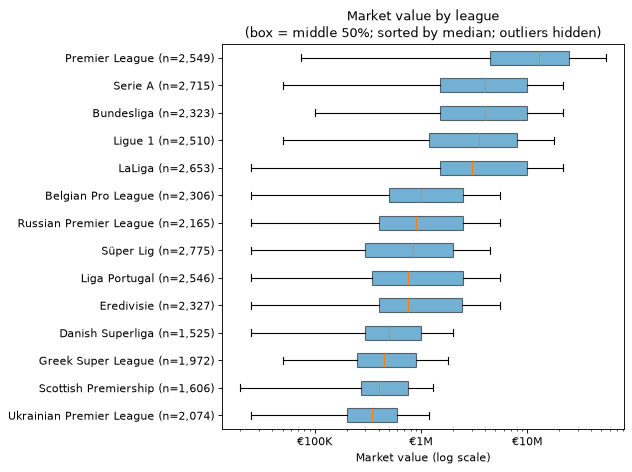

competition
Bundesliga        11.4
Serie A           11.4
Premier League    37.1 
(x times the lowest league median)


,median value (EUR)
competition,
Premier League,13000000.0
Serie A,4000000.0
Bundesliga,4000000.0
Ligue 1,3500000.0
LaLiga,3000000.0
Belgian Pro League,1000000.0
Russian Premier League,900000.0
Süper Lig,850000.0
Liga Portugal,750000.0


In [9]:
lg = df.groupby("competition")[MV].agg(median="median", n="size").sort_values("median")
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot([df.loc[df["competition"] == c, MV] for c in lg.index], orientation="horizontal",
                showfliers=False, patch_artist=True, tick_labels=[f"{c} (n={int(lg.loc[c, 'n']):,})" for c in lg.index])
for patch in bp["boxes"]:
    patch.set_facecolor("#0072B2"); patch.set_alpha(0.55)
ax.set_xscale("log"); ax.xaxis.set_major_formatter(log_eur_axis)
ax.set_xlabel("Market value (log scale)")
ax.set_title("Market value by league\n(box = middle 50%; sorted by median; outliers hidden)")
fig.tight_layout()
fig.savefig(FIG_DIR / "market_value_by_league.png", dpi=150)
plt.show()
print((lg["median"] / lg["median"].min()).round(1).tail(3).to_string(), "\n(x times the lowest league median)")
lg["median"].round(-3).to_frame("median value (EUR)").iloc[::-1]

## Table 1. Spearman correlation with market value, by position

Spearman is rank-based, so it is robust to the skew and to monotone-nonlinear
shapes. Age, minutes, appearances, goals, assists use all rows; per-90
columns use only >= 450-minute rows. Goals/assists are blanked for
goalkeepers (not meaningful). These are *pooled across leagues*.

In [10]:
ALL_COLS = ["age", "total_minutes", "appearances", "goals", "assists"]
RATE_COLS = ["goals_per_90", "assists_per_90"]
ROWS = ALL_COLS + RATE_COLS
GK_BLANK = ["goals", "assists", "goals_per_90", "assists_per_90"]

def spearman_vs_value(sub_all, sub_elig):
    out = sub_all[ALL_COLS + [MV]].corr(method="spearman")[MV].drop(MV)
    rate = sub_elig[RATE_COLS + [MV]].corr(method="spearman")[MV].drop(MV)
    return pd.concat([out, rate])[ROWS]

table1 = pd.DataFrame({"All positions": spearman_vs_value(df, elig)})
for p in POS_ORDER:
    table1[p] = spearman_vs_value(df[df["position"] == p], elig[elig["position"] == p])
table1.loc[GK_BLANK, "Goalkeeper"] = np.nan
table1.round(2)

,All positions,Goalkeeper,Defender,Midfield,Attack
age,-0.03,-0.09,-0.10,0.01,0.05
total_minutes,0.51,0.57,0.47,0.53,0.56
appearances,0.54,0.57,0.49,0.56,0.56
goals,0.40,NaN,0.31,0.44,0.58
assists,0.41,NaN,0.30,0.45,0.53
goals_per_90,0.24,NaN,0.18,0.23,0.37
assists_per_90,0.24,NaN,0.16,0.23,0.30


## Table 2. Does it hold within a league?

Same Spearman correlations, but computed **inside each league** and then
summarised (median across the 14 leagues, requiring >= 100 rows for that
position/league). If the pooled numbers in Table 1 are mostly a league
effect, they will shrink here.

In [11]:
def within_league(pos, col, use_elig):
    base = elig if use_elig else df
    base = base[base["position"] == pos]
    vals = []
    for _, s in base.groupby("competition"):
        if len(s) >= 100:
            vals.append(s[[col, MV]].corr(method="spearman").iloc[0, 1])
    return np.median(vals), len(vals)

rows = {}
for col in ROWS:
    rows[col] = {}
    for p in ["Defender", "Midfield", "Attack", "Goalkeeper"]:
        if p == "Goalkeeper" and col in GK_BLANK:
            rows[col][p] = np.nan; continue
        rows[col][p] = within_league(p, col, col in RATE_COLS)[0]
table2 = pd.DataFrame(rows).T[["Goalkeeper", "Defender", "Midfield", "Attack"]]
print("median of within-league Spearman correlations (leagues with >= 100 rows in that position)")
table2.round(2)

median of within-league Spearman correlations (leagues with >= 100 rows in that position)


,Goalkeeper,Defender,Midfield,Attack
age,-0.17,-0.16,-0.02,0.00
total_minutes,0.62,0.49,0.58,0.60
appearances,0.62,0.48,0.55,0.54
goals,NaN,0.34,0.51,0.63
assists,NaN,0.34,0.52,0.57
goals_per_90,NaN,0.19,0.31,0.44
assists_per_90,NaN,0.18,0.31,0.34


In [12]:
cmp_ = table1[POS_ORDER].round(2).join(table2.round(2), lsuffix=" (pooled)", rsuffix=" (within-league)")
cmp_.loc[["age", "total_minutes", "goals_per_90", "assists_per_90"]]

,Goalkeeper (pooled),Defender (pooled),Midfield (pooled),Attack (pooled),Goalkeeper (within-league),Defender (within-league),Midfield (within-league),Attack (within-league)
age,-0.09,-0.10,0.01,0.05,-0.17,-0.16,-0.02,0.00
total_minutes,0.57,0.47,0.53,0.56,0.62,0.49,0.58,0.60
goals_per_90,NaN,0.18,0.23,0.37,NaN,0.19,0.31,0.44
assists_per_90,NaN,0.16,0.23,0.30,NaN,0.18,0.31,0.34
